<a href="https://colab.research.google.com/github/fa623/ml-code/blob/main/loan_approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [43]:
import kagglehub
path = kagglehub.dataset_download("bhavikjikadara/loan-status-prediction")
import os
path_df=os.path.join(path,"loan_data.csv")
df=pd.read_csv(path_df)
df.head()

Using Colab cache for faster access to the 'loan-status-prediction' dataset.


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [45]:
df["Credit_History"].fillna(df["Credit_History"].mean(),inplace=True)
df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mean(),inplace=True)

In [46]:
df.shape

(381, 13)

In [47]:
df.dropna(subset=["Education"],inplace=True)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   381 non-null    float64
 10  Credit_History     381 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [49]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y = df["Loan_Status"]
y_encode=le.fit_transform(y)

In [50]:
df.columns = df.columns.str.strip()
df["Education"]=le.fit_transform(df["Education"])
df["Self_Employed"]=le.fit_transform(df["Self_Employed"])
df["Loan_Status"]=le.fit_transform(df["Loan_Status"])
df["Gender"] = le.fit_transform(df["Gender"])
df["Married"] = le.fit_transform(df["Married"])
df["Dependents"] = le.fit_transform(df["Dependents"])
df["Property_Area"] = le.fit_transform(df["Property_Area"])

In [51]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
1,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
2,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
3,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1
4,LP001013,1,1,0,1,0,2333,1516.0,95.0,360.0,1.0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,LP002953,1,1,3,0,0,5703,0.0,128.0,360.0,1.0,2,1
377,LP002974,1,1,0,0,0,3232,1950.0,108.0,360.0,1.0,0,1
378,LP002978,0,0,0,0,0,2900,0.0,71.0,360.0,1.0,0,1
379,LP002979,1,1,3,0,0,4106,0.0,40.0,180.0,1.0,0,1


In [52]:
x = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [53]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y_encode)

In [54]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

x_train = x_train.drop('Loan_ID', axis=1)
x_test = x_test.drop('Loan_ID', axis=1)

model.fit(x_train,y_train)

LogisticRegression()

In [55]:
y_pred=model.predict(x_test)

In [56]:
from sklearn.metrics import accuracy_score

In [57]:
accuracy_score(y_test,y_pred)

0.8441558441558441

In [58]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[11, 11],
       [ 1, 54]])

In [59]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(x_train,y_train)

GaussianNB()

In [60]:
y_pred=model.predict(x_test)

In [61]:
accuracy_score(y_test,y_pred)

0.8441558441558441

In [62]:
from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier()
model.fit(x_train,y_train)

KNeighborsClassifier()

In [63]:
y_pred=model.predict(x_test)

In [64]:
accuracy_score(y_test,y_pred)

0.7662337662337663

In [65]:
from sklearn.svm import SVC
model=SVC(kernel='rbf', C=1, gamma='scale')
model.fit(x_train,y_train)

SVC(C=1)

In [66]:
y_pred=model.predict(x_test)

In [67]:
accuracy_score(y_test,y_pred)

0.7142857142857143

In [68]:
from xgboost import XGBClassifier
model=XGBClassifier(n_estimators=100,random_state=42,learning_rate=0.1,max_depth=3,use_label_encoder=False,eval_metrics='mlogloss')
model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None,
              eval_metrics='mlogloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, ...)

In [69]:
y_pred=model.predict(x_test)

In [70]:
accuracy_score(y_test,y_pred)

0.8571428571428571

In [71]:
prediction_on_training_data = model.predict(x_train)
accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)
print(accuracy_on_training_data)

0.9177631578947368


In [72]:
prediction_on_testing_data=model.predict(x_test)
accuracy_on_testing_data=accuracy_score(y_test,prediction_on_testing_data)
accuracy_on_testing_data

0.8571428571428571

<Axes: ylabel='count'>

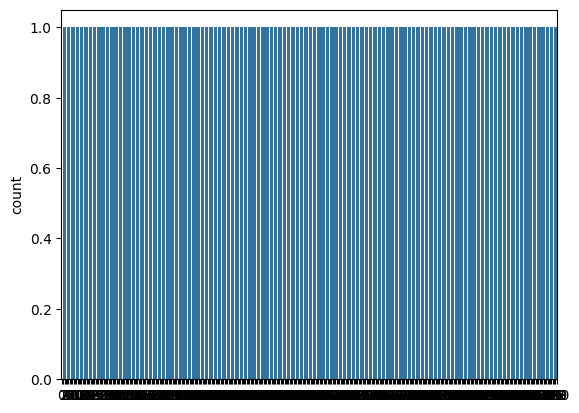

In [73]:
sns.countplot(df["Loan_Status"])

<Axes: >

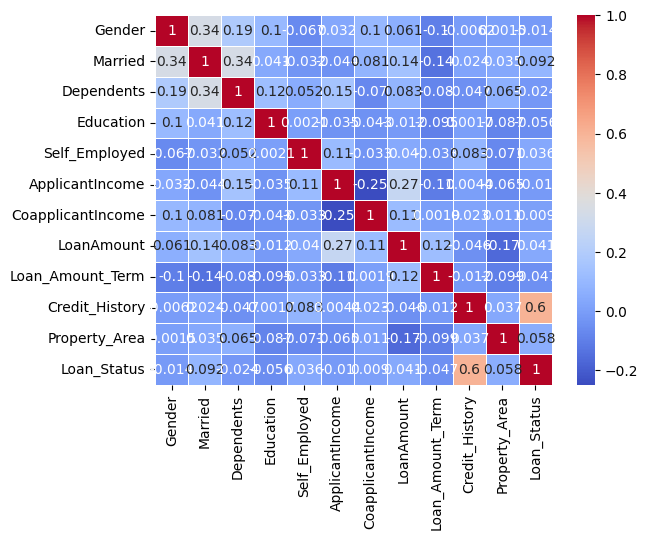

In [74]:
uniform_data = df.drop('Loan_ID', axis=1).corr()
sns.heatmap(uniform_data, annot=True, cmap="coolwarm", linewidths=0.5)

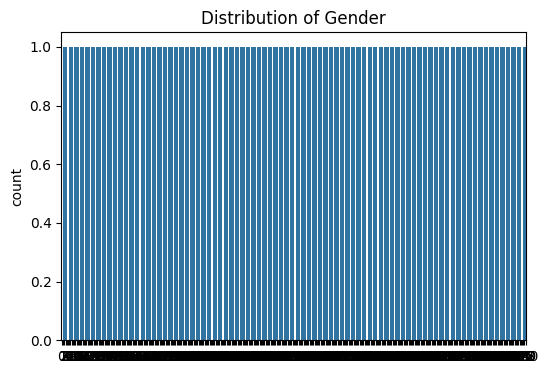

In [75]:
plt.figure(figsize=(6,4))
sns.countplot(df["Gender"])
plt.title("Distribution of Gender")
plt.show()

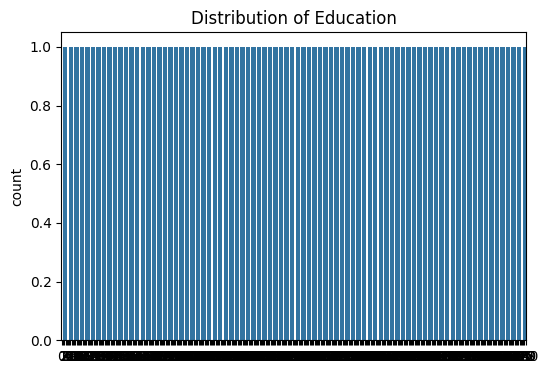

In [76]:
plt.figure(figsize=(6,4))
sns.countplot(df["Education"])
plt.title("Distribution of Education")
plt.show()

<Axes: xlabel='Gender', ylabel='Loan_Status'>

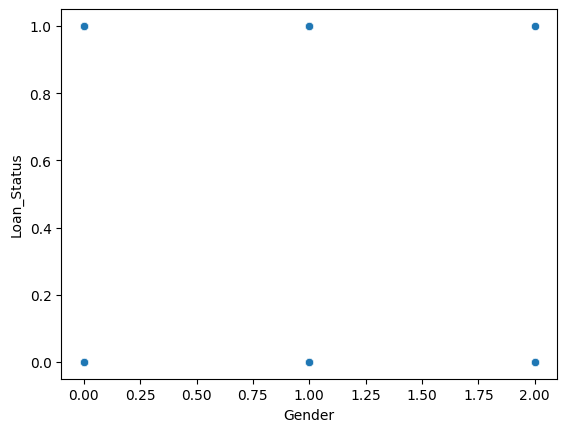

In [77]:
sns.scatterplot(x="Gender",y="Loan_Status",data=df)